# PHASE 3 — ANALYSIS 3.1: Excitation Effect & Narrative Shift Trigger
## Langkah 3: Statistical Integration
## Langkah 4: Trigger Point Identification (Fixed)

**Langkah 3:** Menggabungkan tiga dimensi (diffusion score, structural penetration, velocity) ke dalam satu framework terintegrasi.

**Langkah 4:** Trace cascade dari tweet pertama Affan Kurniawan — identifikasi trigger point dan pola penyebaran.

**FIX:** Affan Kurniawan tweets di-filter dari 28 Agustus 2025 ke depan. Tweet sebelum tanggal tersebut adalah misclassification BERTopic (Affan meninggal 28 Agustus — tidak mungkin ada tweet tentang dia sebelumnya).

**Input files:**
- `Data_with_community2.csv`
- `Data_diffusion_analysis2.csv`
- `penetration_by_narrative.csv`
- `network_edges.csv`
- `network_nodes_with_community2.csv`

## Cell 1: Import & Load

In [1]:
!pip install networkx -q

import pandas as pd
import numpy as np
import networkx as nx
from scipy import stats
from scipy.stats import zscore
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# Load all data
df_comm = pd.read_csv('Data_with_community2.csv')
df_diff = pd.read_csv('Data_diffusion_analysis2.csv')
pen = pd.read_csv('penetration_by_narrative.csv')
edges = pd.read_csv('network_edges.csv')
nodes = pd.read_csv('network_nodes_with_community2.csv')

# Merge diffusion score ke base data
df = df_comm.merge(
    df_diff[['tweet_url', 'diffusion_score']],
    on='tweet_url', how='left'
)
df['date'] = pd.to_datetime(df['date'])

engagement_cols = ['retweet_count', 'reply_count', 'quote_count', 'favorite_count', 'view_count']
for col in engagement_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
df['total_engagement'] = df[engagement_cols].sum(axis=1)

shift_date = pd.Timestamp('2025-08-27')
df['phase'] = df['date'].apply(lambda x: 'Pre-shift' if x < shift_date else 'Post-shift')

# Community lookup
community_lookup = dict(zip(nodes['username'], nodes['community']))

# Filter @barengwarga
bw_mask = df['username'].str.lower().str.strip().str.replace('@', '') == 'barengwarga'
df_clean = df[~bw_mask].copy()

# Affan temporal filter: hanya dari 28 Agustus
affan_cutoff = pd.Timestamp('2025-08-28')

print(f"Data loaded: {len(df)} tweets")
print(f"Without @barengwarga: {len(df_clean)} tweets")
print(f"Affan Kurniawan total: {len(df[df['narrative'] == 'Affan Kurniawan'])}")
print(f"Affan Kurniawan from 28 Aug: {len(df[(df['narrative'] == 'Affan Kurniawan') & (df['date'] >= affan_cutoff)])}")
print(f"Affan misclassified removed: {len(df[(df['narrative'] == 'Affan Kurniawan') & (df['date'] < affan_cutoff)])}")

Data loaded: 14248 tweets
Without @barengwarga: 14237 tweets
Affan Kurniawan total: 743
Affan Kurniawan from 28 Aug: 729
Affan misclassified removed: 14


---
# LANGKAH 3: STATISTICAL INTEGRATION

Menggabungkan tiga dimensi per narasi:
1. **Diffusion** — mean diffusion score (dari Analysis 2.1)
2. **Structural Penetration** — max hop, avg hop, cross-community ratio (dari Analysis 2.2)
3. **Velocity** — engagement per day, mean engagement per tweet (dari Langkah 2)

Semua dihitung TANPA @barengwarga.

## Cell 2: Build Integrated Excitation Table

In [2]:
# === DIMENSI 1: DIFFUSION SCORE ===
df_with_diff = df_clean[df_clean['diffusion_score'].notna()]
dim1 = df_with_diff.groupby('narrative').agg(
    mean_diffusion=('diffusion_score', 'mean'),
    median_diffusion=('diffusion_score', 'median')
).reset_index()

# === DIMENSI 2: STRUCTURAL PENETRATION (dari penetration_by_narrative.csv) ===
dim2 = pen[['narrative', 'max_hop', 'avg_hop', 'cross_ratio', 'communities_reached',
             'reach_pct', 'cross_edges', 'total_edges']].copy()

# === DIMENSI 3: VELOCITY (post-shift only, tanpa @barengwarga) ===
df_post = df_clean[df_clean['phase'] == 'Post-shift']

velocity_data = []
for narr in df_post['narrative'].dropna().unique():
    subset = df_post[df_post['narrative'] == narr]
    n_days = subset['date'].dt.date.nunique()
    if n_days == 0:
        continue

    daily = subset.groupby(subset['date'].dt.date)['total_engagement'].sum()
    peak_day_eng = daily.max()
    peak_date = pd.Timestamp(daily.idxmax())
    days_from_shift = (peak_date - shift_date).days

    velocity_data.append({
        'narrative': narr,
        'post_tweets': len(subset),
        'post_eng_per_day': subset['total_engagement'].sum() / n_days,
        'post_mean_eng_per_tweet': subset['total_engagement'].mean(),
        'post_median_eng_per_tweet': subset['total_engagement'].median(),
        'peak_day_engagement': peak_day_eng,
        'days_to_peak_from_shift': days_from_shift
    })

dim3 = pd.DataFrame(velocity_data)

# === MERGE ALL THREE DIMENSIONS ===
integrated = dim2.merge(dim1, on='narrative', how='left')
integrated = integrated.merge(dim3, on='narrative', how='left')
integrated = integrated.sort_values('max_hop', ascending=False)

print("=" * 90)
print("INTEGRATED EXCITATION TABLE — ALL THREE DIMENSIONS")
print("=" * 90)
print()

display_cols = ['narrative', 'mean_diffusion', 'max_hop', 'avg_hop', 'cross_ratio',
                'communities_reached', 'post_eng_per_day', 'post_mean_eng_per_tweet',
                'post_median_eng_per_tweet', 'days_to_peak_from_shift']

print(integrated[display_cols].to_string(index=False))

INTEGRATED EXCITATION TABLE — ALL THREE DIMENSIONS

         narrative  mean_diffusion  max_hop  avg_hop  cross_ratio  communities_reached  post_eng_per_day  post_mean_eng_per_tweet  post_median_eng_per_tweet  days_to_peak_from_shift
   Affan Kurniawan        0.532106        7     2.84         13.7                  102     353610.000000              6790.864198                      360.0                        4
Keamanan & Respons        0.233325        5     2.63         18.4                   68      52000.111111              6240.013333                      227.5                        2
        Demo & DPR        0.001784        5     2.27          6.4                  683      37883.736842               766.550586                        0.0                        5
    Ekonomi Rakyat       -0.058449        4     2.00         14.5                  154      44124.923077              1348.117509                       56.0                        3
  Kekerasan Aparat       -0.050403    

## Cell 3: Correlation Analysis — Do the Three Dimensions Align?

In [3]:
corr_cols = [
    'mean_diffusion',
    'max_hop',
    'avg_hop',
    'cross_ratio',
    'post_eng_per_day',
    'post_mean_eng_per_tweet',
    'post_median_eng_per_tweet'
]

corr_data = integrated[corr_cols].dropna()

print("=" * 70)
print("SPEARMAN RANK CORRELATION MATRIX")
print("=" * 70)
print(f"n = {len(corr_data)} narratives\n")

results = []
for i, col1 in enumerate(corr_cols):
    for col2 in corr_cols[i+1:]:
        rho, p = stats.spearmanr(corr_data[col1], corr_data[col2])
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        results.append({
            'var1': col1, 'var2': col2,
            'rho': round(rho, 3), 'p': round(p, 4), 'sig': sig
        })

df_corr = pd.DataFrame(results)
print(df_corr.to_string(index=False))

print("\n" + "=" * 70)
print("KEY CROSS-DIMENSION CORRELATIONS")
print("=" * 70)

key_pairs = [
    ('mean_diffusion', 'max_hop', 'Diffusion <-> Max Hop (Dim1 <-> Dim2)'),
    ('mean_diffusion', 'post_median_eng_per_tweet', 'Diffusion <-> Median Engagement (Dim1 <-> Dim3)'),
    ('max_hop', 'post_median_eng_per_tweet', 'Max Hop <-> Median Engagement (Dim2 <-> Dim3)'),
    ('avg_hop', 'post_eng_per_day', 'Avg Hop <-> Engagement/Day (Dim2 <-> Dim3)'),
    ('cross_ratio', 'mean_diffusion', 'Cross-Comm Ratio <-> Diffusion (Dim2 <-> Dim1)')
]

for col1, col2, label in key_pairs:
    rho, p = stats.spearmanr(corr_data[col1], corr_data[col2])
    print(f"{label}: rho={rho:.3f}, p={p:.4f}")

SPEARMAN RANK CORRELATION MATRIX
n = 7 narratives

                   var1                      var2    rho      p sig
         mean_diffusion                   max_hop  0.385 0.3931  ns
         mean_diffusion                   avg_hop  0.429 0.3374  ns
         mean_diffusion               cross_ratio  0.321 0.4821  ns
         mean_diffusion          post_eng_per_day  0.250 0.5887  ns
         mean_diffusion   post_mean_eng_per_tweet  0.536 0.2152  ns
         mean_diffusion post_median_eng_per_tweet  0.607 0.1482  ns
                max_hop                   avg_hop  0.973 0.0002 ***
                max_hop               cross_ratio -0.642 0.1197  ns
                max_hop          post_eng_per_day  0.385 0.3931  ns
                max_hop   post_mean_eng_per_tweet  0.532 0.2187  ns
                max_hop post_median_eng_per_tweet  0.385 0.3931  ns
                avg_hop               cross_ratio -0.500 0.2532  ns
                avg_hop          post_eng_per_day  0.286 0.5345  

## Cell 4: Excitation Effect Index

EXCITATION EFFECT INDEX — COMPOSITE RANKING

 rank          narrative  mean_diffusion  max_hop  avg_hop  post_median_eng_per_tweet  excitation_index
    1    Affan Kurniawan        0.532106        7     2.84                      360.0          1.972663
    2 Keamanan & Respons        0.233325        5     2.63                      227.5          0.787352
    3         Demo & DPR        0.001784        5     2.27                        0.0         -0.226035
    4     Ekonomi Rakyat       -0.058449        4     2.00                       56.0         -0.561194
    5   Kekerasan Aparat       -0.050403        4     1.93                       68.0         -0.573176
    6    Gerakan/Hashtag        0.002605        3     1.83                      104.0         -0.691341
    7 Politik & Tuntutan        0.101300        3     1.87                       23.0         -0.708269


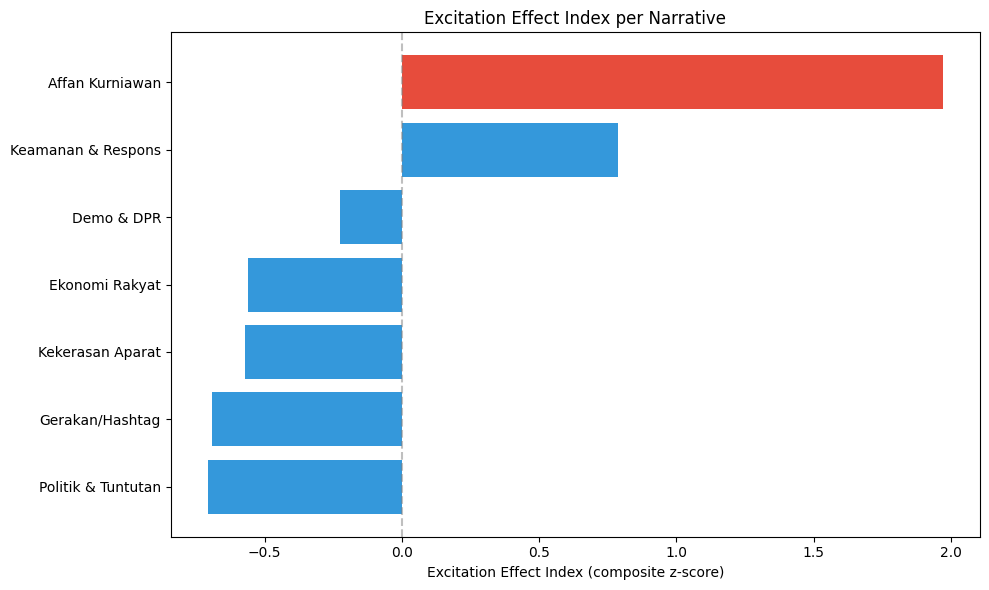

In [4]:
excitation_metrics = [
    'mean_diffusion',
    'max_hop',
    'avg_hop',
    'post_median_eng_per_tweet'
]

exc_data = integrated[['narrative'] + excitation_metrics].dropna().copy()

for col in excitation_metrics:
    exc_data[f'{col}_z'] = zscore(exc_data[col])

z_cols = [f'{col}_z' for col in excitation_metrics]
exc_data['excitation_index'] = exc_data[z_cols].mean(axis=1)

exc_data = exc_data.sort_values('excitation_index', ascending=False)
exc_data['rank'] = range(1, len(exc_data) + 1)

print("=" * 70)
print("EXCITATION EFFECT INDEX — COMPOSITE RANKING")
print("=" * 70)
print()
print(exc_data[['rank', 'narrative'] + excitation_metrics + ['excitation_index']].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['#e74c3c' if 'Affan' in n else '#3498db' for n in exc_data['narrative']]
bars = ax.barh(range(len(exc_data)), exc_data['excitation_index'], color=colors_bar)
ax.set_yticks(range(len(exc_data)))
ax.set_yticklabels(exc_data['narrative'])
ax.set_xlabel('Excitation Effect Index (composite z-score)')
ax.set_title('Excitation Effect Index per Narrative')
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Cell 5: Pre vs Post Shift — Excitation Multiplier

In [5]:
print("=" * 80)
print("EXCITATION MULTIPLIER — POST/PRE RATIO PER NARRATIVE (tanpa @barengwarga)")
print("=" * 80)

key_narratives = ['Demo & DPR', 'Affan Kurniawan', 'Kekerasan Aparat', 'Politik & Tuntutan', 'Ekonomi Rakyat']

multiplier_data = []
for narr in key_narratives:
    pre = df_clean[(df_clean['narrative'] == narr) & (df_clean['phase'] == 'Pre-shift')]
    post = df_clean[(df_clean['narrative'] == narr) & (df_clean['phase'] == 'Post-shift')]

    if len(pre) == 0 or len(post) == 0:
        continue

    pre_eng = pre['total_engagement'].mean()
    post_eng = post['total_engagement'].mean()
    pre_median = pre['total_engagement'].median()
    post_median = post['total_engagement'].median()

    df_with_diff_narr = df_with_diff[df_with_diff['narrative'] == narr]
    pre_d = df_with_diff_narr[df_with_diff_narr['phase'] == 'Pre-shift']['diffusion_score'].mean()
    post_d = df_with_diff_narr[df_with_diff_narr['phase'] == 'Post-shift']['diffusion_score'].mean()

    pre_tweets_day = len(pre) / pre['date'].dt.date.nunique() if pre['date'].dt.date.nunique() > 0 else 0
    post_tweets_day = len(post) / post['date'].dt.date.nunique() if post['date'].dt.date.nunique() > 0 else 0

    multiplier_data.append({
        'narrative': narr,
        'pre_mean_eng': round(pre_eng, 1),
        'post_mean_eng': round(post_eng, 1),
        'mean_eng_multiplier': round(post_eng / pre_eng, 1) if pre_eng > 0 else np.inf,
        'pre_median_eng': round(pre_median, 1),
        'post_median_eng': round(post_median, 1),
        'median_eng_multiplier': round(post_median / pre_median, 1) if pre_median > 0 else np.inf,
        'pre_diffusion': round(pre_d, 4) if not np.isnan(pre_d) else None,
        'post_diffusion': round(post_d, 4) if not np.isnan(post_d) else None,
        'tweets_per_day_multiplier': round(post_tweets_day / pre_tweets_day, 1) if pre_tweets_day > 0 else np.inf
    })

df_mult = pd.DataFrame(multiplier_data)
print(df_mult.to_string(index=False))

EXCITATION MULTIPLIER — POST/PRE RATIO PER NARRATIVE (tanpa @barengwarga)
         narrative  pre_mean_eng  post_mean_eng  mean_eng_multiplier  pre_median_eng  post_median_eng  median_eng_multiplier  pre_diffusion  post_diffusion  tweets_per_day_multiplier
        Demo & DPR        1409.7          766.6                  0.5            74.0              0.0                    0.0        -0.0243          0.1062                        0.8
   Affan Kurniawan         656.8         6790.9                 10.3            38.0            360.0                    9.5        -0.0729          0.5424                       37.2
  Kekerasan Aparat         975.6         2127.8                  2.2            55.0             68.0                    1.2        -0.1585         -0.0076                        3.5
Politik & Tuntutan        1617.4          559.5                  0.3           129.0             23.0                    0.2         0.2330         -0.0503                        1.4
    Ekonomi

---
# LANGKAH 4: TRIGGER POINT IDENTIFICATION (FIXED)

Affan Kurniawan di-filter dari 28 Agustus 2025 ke depan.
Tweet sebelumnya adalah misclassification BERTopic.

## Cell 6: First 20 Tweets — Affan Kurniawan (Fixed)

In [6]:
# Filter Affan dari 28 Agustus
affan = df[
    (df['narrative'] == 'Affan Kurniawan') &
    (df['date'] >= affan_cutoff)
].sort_values('date').copy()

print(f"Affan Kurniawan tweets (dari 28 Aug): {len(affan)}")
print(f"Removed: {len(df[df['narrative'] == 'Affan Kurniawan']) - len(affan)} misclassified tweets")

print("\n" + "=" * 80)
print("FIRST 20 TWEETS — AFFAN KURNIAWAN (dari 28 Agustus)")
print("=" * 80)

for i, (_, row) in enumerate(affan.head(20).iterrows()):
    print(f"\n--- #{i+1} | {row['date']} ---")
    print(f"@{row['username']} ({row['account_type']}) | Community {row['community']}")
    print(f"RT:{int(row['retweet_count'])} Reply:{int(row['reply_count'])} Quote:{int(row['quote_count'])} Fav:{int(row['favorite_count'])} View:{int(row['view_count'])}")
    print(f"Engagement: {int(row['total_engagement']):,}")

    if pd.notna(row.get('in_reply_to_screen_name')):
        print(f"Reply to: @{row['in_reply_to_screen_name']}")
    if pd.notna(row.get('quoted_username')):
        print(f"Quote of: @{row['quoted_username']}")

    print(f"Text: {str(row['full_text'])[:250]}")
    print(f"URL: {row['tweet_url']}")

Affan Kurniawan tweets (dari 28 Aug): 729
Removed: 14 misclassified tweets

FIRST 20 TWEETS — AFFAN KURNIAWAN (dari 28 Agustus)

--- #1 | 2025-08-28 15:25:00 ---
@@bekalicky (grassroot) | Community 16
RT:0 Reply:0 Quote:0 Fav:0 View:356
Engagement: 356
Text: rest in piece tuan affan kurniawan

anda akan kami kenang sebagai korban penyelewengan demokrasi indonesia
rip ojol korban demo tunjangan dprri indonesiagelap
URL: https://x.com/bekalicky/status/1961087840961654855

--- #2 | 2025-08-28 16:12:00 ---
@@antoTBL (grassroot) | Community 9
RT:0 Reply:0 Quote:0 Fav:0 View:483
Engagement: 483
Quote of: @Casiphiaaaaa
Text: pak jemmy apapun jabatan anda di brimob statemen anda wajib di pertanggung jawabkan hukum pelaku sesuai hukum sipil
indonesiagelap
URL: https://x.com/antoTBL/status/1961099611051061295

--- #3 | 2025-08-28 16:13:00 ---
@@republikaonline (media/news) | Community 89
RT:0 Reply:0 Quote:0 Fav:0 View:0
Engagement: 0
Text: mobil rantis brimob itu tampak terus melaju saat korban

## Cell 7: Hourly Cascade — First 72 Hours

In [7]:
affan['hour_bin'] = affan['date'].dt.floor('h')

first_tweet_time = affan['date'].min()
cutoff_72h = first_tweet_time + pd.Timedelta(hours=72)

affan_early = affan[affan['date'] <= cutoff_72h].copy()

print(f"First Affan tweet: {first_tweet_time}")
print(f"Analyzing first 72 hours until: {cutoff_72h}")
print(f"Tweets in 72h window: {len(affan_early)}")

hourly = affan_early.groupby('hour_bin').agg(
    n_tweets=('total_engagement', 'size'),
    total_engagement=('total_engagement', 'sum'),
    unique_users=('username', 'nunique'),
    unique_communities=('community', 'nunique'),
    communities=('community', lambda x: sorted(x.dropna().unique().tolist())),
    account_types=('account_type', lambda x: dict(x.value_counts()))
).reset_index()

all_comms_so_far = set()
cum_comms = []
for _, row in hourly.iterrows():
    all_comms_so_far.update(row['communities'])
    cum_comms.append(len(all_comms_so_far))
hourly['cumulative_communities'] = cum_comms

print("\n" + "=" * 80)
print("HOURLY CASCADE — FIRST 72 HOURS OF AFFAN KURNIAWAN NARRATIVE")
print("=" * 80)

for _, row in hourly.iterrows():
    hours_elapsed = (row['hour_bin'] - first_tweet_time).total_seconds() / 3600
    print(f"\nH+{hours_elapsed:>5.0f} | {row['hour_bin']} | "
          f"Tweets: {row['n_tweets']:>3} | Users: {row['unique_users']:>3} | "
          f"New comms: {row['unique_communities']:>2} | Cumul comms: {row['cumulative_communities']:>3} | "
          f"Engagement: {int(row['total_engagement']):>10,}")
    print(f"         Types: {row['account_types']}")

First Affan tweet: 2025-08-28 15:25:00
Analyzing first 72 hours until: 2025-08-31 15:25:00
Tweets in 72h window: 315

HOURLY CASCADE — FIRST 72 HOURS OF AFFAN KURNIAWAN NARRATIVE

H+   -0 | 2025-08-28 15:00:00 | Tweets:   1 | Users:   1 | New comms:  1 | Cumul comms:   1 | Engagement:        356
         Types: {'grassroot': np.int64(1)}

H+    1 | 2025-08-28 16:00:00 | Tweets:   4 | Users:   4 | New comms:  4 | Cumul comms:   5 | Engagement:        483
         Types: {'media/news': np.int64(3), 'grassroot': np.int64(1)}

H+    2 | 2025-08-28 17:00:00 | Tweets:   2 | Users:   2 | New comms:  2 | Cumul comms:   7 | Engagement:          0
         Types: {'media/news': np.int64(1), 'grassroot': np.int64(1)}

H+    3 | 2025-08-28 18:00:00 | Tweets:   3 | Users:   3 | New comms:  3 | Cumul comms:  10 | Engagement:        600
         Types: {'grassroot': np.int64(2), 'media/news': np.int64(1)}

H+    4 | 2025-08-28 19:00:00 | Tweets:   1 | Users:   1 | New comms:  1 | Cumul comms:  11 | E

## Cell 8: Community Propagation Order (Fixed)

In [8]:
community_first = affan.groupby('community').agg(
    first_tweet=('date', 'min'),
    first_user=('username', 'first'),
    first_account_type=('account_type', 'first'),
    total_tweets=('date', 'size'),
    total_engagement=('total_engagement', 'sum'),
    unique_users=('username', 'nunique')
).reset_index()

community_first = community_first.sort_values('first_tweet')
community_first['order'] = range(1, len(community_first) + 1)
community_first['hours_from_first'] = (
    (community_first['first_tweet'] - community_first['first_tweet'].min())
    .dt.total_seconds() / 3600
).round(1)

print("=" * 90)
print("COMMUNITY PROPAGATION ORDER — AFFAN KURNIAWAN (dari 28 Agustus)")
print("=" * 90)
print(f"Total communities reached: {len(community_first)}")
print(f"Time span: {community_first['hours_from_first'].max():.0f} hours\n")

print("First 30 communities infected:")
print(community_first[['order', 'community', 'first_tweet', 'hours_from_first',
                        'first_user', 'first_account_type', 'total_tweets',
                        'unique_users', 'total_engagement']].head(30).to_string(index=False))

print(f"\n{'=' * 70}")
print("ACCOUNT TYPE OF FIRST-MOVERS (who introduced Affan to each community)")
print("=" * 70)
print(community_first['first_account_type'].value_counts())
print(f"\nGrassroot as first-mover: {(community_first['first_account_type'] == 'grassroot').mean()*100:.1f}%")

COMMUNITY PROPAGATION ORDER — AFFAN KURNIAWAN (dari 28 Agustus)
Total communities reached: 100
Time span: 334 hours

First 30 communities infected:
 order  community         first_tweet  hours_from_first       first_user first_account_type  total_tweets  unique_users  total_engagement
     1         16 2025-08-28 15:25:00               0.0       @bekalicky          grassroot            32             8          383771.0
     2          9 2025-08-28 16:12:00               0.8         @antoTBL          grassroot            70            36          385217.0
     3         89 2025-08-28 16:13:00               0.8 @republikaonline         media/news             3             3            3197.0
     4         74 2025-08-28 16:40:00               1.2      @Beritasatu         media/news            10             3           15486.0
     5         49 2025-08-28 16:44:00               1.3  @merapi_uncover         media/news            21            13           73890.0
     6         11 2025-0

## Cell 9: Community Propagation Visualization (Fixed)

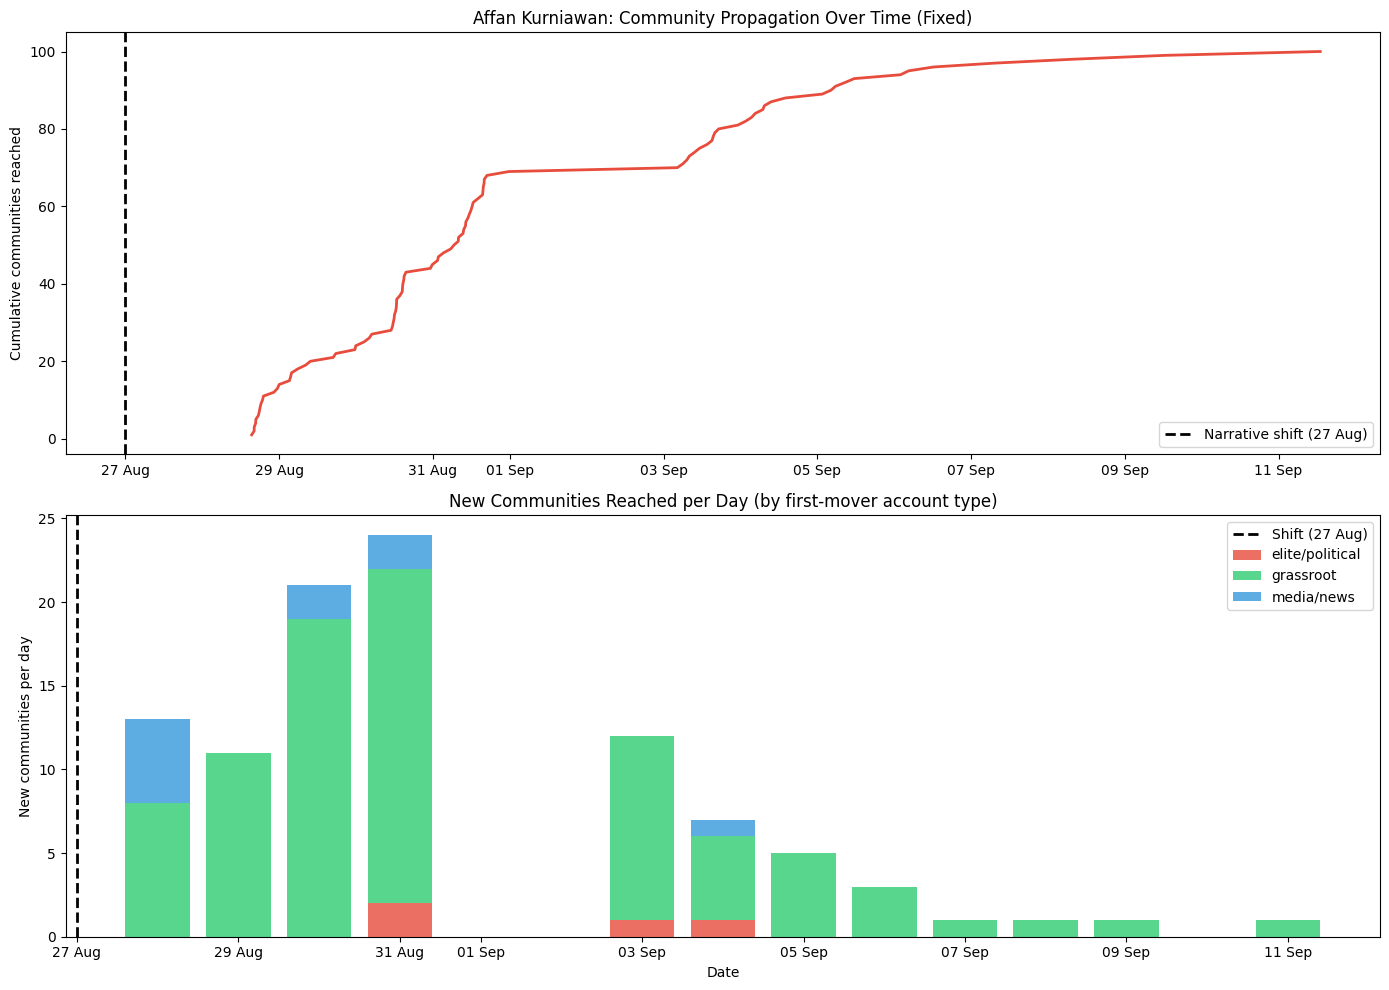

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Cumulative communities
axes[0].plot(community_first['first_tweet'], community_first['order'],
            color='#e74c3c', linewidth=2)
axes[0].axvline(x=shift_date, color='black', linestyle='--', linewidth=2, label='Narrative shift (27 Aug)')
axes[0].set_ylabel('Cumulative communities reached')
axes[0].set_title('Affan Kurniawan: Community Propagation Over Time (Fixed)')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

# Plot 2: New communities per day by account type
community_first['date_day'] = community_first['first_tweet'].dt.date
daily_new = community_first.groupby(['date_day', 'first_account_type']).size().unstack(fill_value=0)
daily_new.index = pd.to_datetime(daily_new.index)

color_map = {'grassroot': '#2ecc71', 'media/news': '#3498db', 'elite/political': '#e74c3c'}
bottom = np.zeros(len(daily_new))

for acct_type in daily_new.columns:
    axes[1].bar(daily_new.index, daily_new[acct_type], bottom=bottom,
               label=acct_type, color=color_map.get(acct_type, 'gray'), alpha=0.8)
    bottom += daily_new[acct_type].values

axes[1].axvline(x=shift_date, color='black', linestyle='--', linewidth=2, label='Shift (27 Aug)')
axes[1].set_ylabel('New communities per day')
axes[1].set_xlabel('Date')
axes[1].set_title('New Communities Reached per Day (by first-mover account type)')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

plt.tight_layout()
plt.show()

## Cell 10: Cascade Comparison — All Narratives (Affan Fixed)

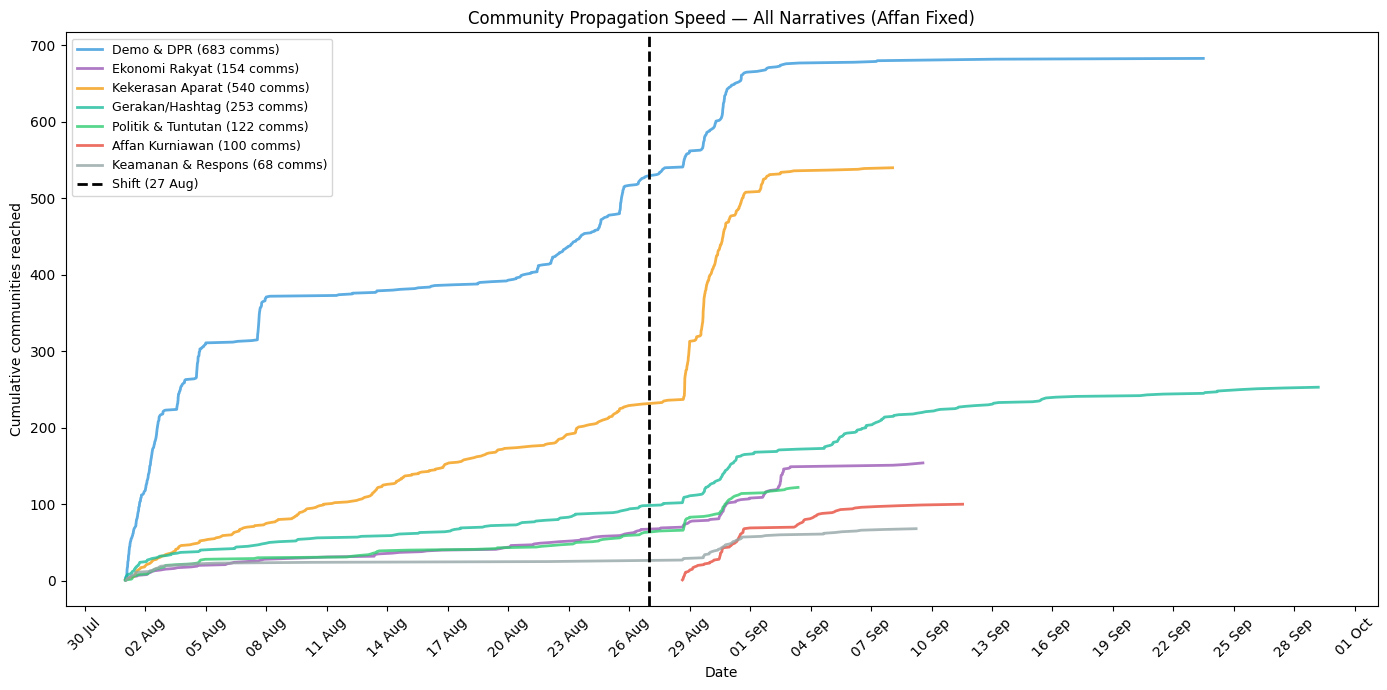

In [10]:
fig, ax = plt.subplots(figsize=(14, 7))

colors_line = {
    'Demo & DPR': '#3498db',
    'Affan Kurniawan': '#e74c3c',
    'Kekerasan Aparat': '#f39c12',
    'Politik & Tuntutan': '#2ecc71',
    'Ekonomi Rakyat': '#9b59b6',
    'Gerakan/Hashtag': '#1abc9c',
    'Keamanan & Respons': '#95a5a6'
}

for narr in df['narrative'].dropna().unique():
    if narr == 'Affan Kurniawan':
        narr_data = affan
    else:
        narr_data = df[df['narrative'] == narr].sort_values('date')

    comm_first_narr = narr_data.groupby('community')['date'].min().sort_values()

    if len(comm_first_narr) < 3:
        continue

    ax.plot(comm_first_narr.values, range(1, len(comm_first_narr) + 1),
           label=f"{narr} ({len(comm_first_narr)} comms)",
           color=colors_line.get(narr, 'gray'), linewidth=2, alpha=0.8)

ax.axvline(x=shift_date, color='black', linestyle='--', linewidth=2, label='Shift (27 Aug)')
ax.set_ylabel('Cumulative communities reached')
ax.set_xlabel('Date')
ax.set_title('Community Propagation Speed — All Narratives (Affan Fixed)')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Cell 11: Trigger Event Timeline Summary (Fixed)

In [11]:
print("=" * 80)
print("TRIGGER EVENT TIMELINE — NARRATIVE SHIFT CASCADE (Fixed)")
print("=" * 80)

for narr in ['Demo & DPR', 'Kekerasan Aparat', 'Affan Kurniawan', 'Politik & Tuntutan', 'Ekonomi Rakyat']:
    if narr == 'Affan Kurniawan':
        subset = affan[~affan['username'].str.lower().str.strip().str.replace('@', '').eq('barengwarga')]
    else:
        subset = df_clean[df_clean['narrative'] == narr].sort_values('date')

    if len(subset) == 0:
        continue

    first_tweet = subset.sort_values('date').iloc[0]
    top_tweet = subset.loc[subset['total_engagement'].idxmax()]

    daily = subset.groupby(subset['date'].dt.date)['total_engagement'].sum()
    peak_date = pd.Timestamp(daily.idxmax())

    comm_first_narr = subset.groupby('community')['date'].min().sort_values()
    half_comms = len(comm_first_narr) // 2
    if half_comms > 0 and half_comms < len(comm_first_narr):
        time_to_half = (comm_first_narr.iloc[half_comms] - comm_first_narr.iloc[0]).total_seconds() / 3600
    else:
        time_to_half = None

    print(f"\n--- {narr} ---")
    print(f"First tweet: {first_tweet['date']} by @{first_tweet['username']} ({first_tweet['account_type']})")
    print(f"Peak day: {peak_date.strftime('%d %b %Y')} (relative to shift: {(peak_date - shift_date).days:+d} days)")
    print(f"Top tweet: @{top_tweet['username']} ({top_tweet['account_type']}) — {int(top_tweet['total_engagement']):,} engagement")
    print(f"Communities reached: {len(comm_first_narr)}")
    if time_to_half:
        print(f"Time to reach 50% communities: {time_to_half:.0f} hours")

    top10 = subset.nlargest(10, 'total_engagement')['account_type'].value_counts()
    print(f"Top 10 tweets by account type: {dict(top10)}")

TRIGGER EVENT TIMELINE — NARRATIVE SHIFT CASCADE (Fixed)

--- Demo & DPR ---
First tweet: 2025-08-01 00:01:00 by @@solehudien30 (grassroot)
Peak day: 25 Aug 2025 (relative to shift: -2 days)
Top tweet: @@qnathania58 (grassroot) — 382,313 engagement
Communities reached: 683
Time to reach 50% communities: 159 hours
Top 10 tweets by account type: {'grassroot': np.int64(8), 'media/news': np.int64(2)}

--- Kekerasan Aparat ---
First tweet: 2025-08-01 00:08:00 by @@ropsable (grassroot)
Peak day: 28 Aug 2025 (relative to shift: +1 days)
Top tweet: @@RahmaPil (grassroot) — 515,864 engagement
Communities reached: 540
Time to reach 50% communities: 667 hours
Top 10 tweets by account type: {'grassroot': np.int64(10)}

--- Affan Kurniawan ---
First tweet: 2025-08-28 15:25:00 by @@bekalicky (grassroot)
Peak day: 31 Aug 2025 (relative to shift: +4 days)
Top tweet: @@ardisatriawan (grassroot) — 897,399 engagement
Communities reached: 100
Time to reach 50% communities: 65 hours
Top 10 tweets by accoun

## Cell 12: Narrative Bridge — Kekerasan Aparat <-> Affan Kurniawan

In [12]:
kek = df[df['narrative'] == 'Kekerasan Aparat']
affan_all = affan  # Already filtered from 28 Aug

kek_users = set(kek['username'].unique())
affan_users = set(affan_all['username'].unique())
overlap_users = kek_users & affan_users

kek_comms = set(kek['community'].dropna().unique())
affan_comms = set(affan_all['community'].dropna().unique())
overlap_comms = kek_comms & affan_comms

print("=" * 70)
print("NARRATIVE BRIDGE: KEKERASAN APARAT <-> AFFAN KURNIAWAN (Fixed)")
print("=" * 70)
print(f"\nUsers in Kekerasan Aparat: {len(kek_users)}")
print(f"Users in Affan Kurniawan: {len(affan_users)}")
print(f"Users in BOTH: {len(overlap_users)} ({len(overlap_users)/len(affan_users)*100:.1f}% of Affan users)")

print(f"\nCommunities in Kekerasan Aparat: {len(kek_comms)}")
print(f"Communities in Affan Kurniawan: {len(affan_comms)}")
print(f"Communities in BOTH: {len(overlap_comms)} ({len(overlap_comms)/len(affan_comms)*100:.1f}% of Affan communities)")

if len(overlap_users) > 0:
    print(f"\n--- Timeline of overlap users ---")
    timeline_data = []
    for user in list(overlap_users)[:20]:
        first_kek = kek[kek['username'] == user]['date'].min()
        first_aff = affan_all[affan_all['username'] == user]['date'].min()
        direction = 'Kekerasan -> Affan' if first_kek < first_aff else 'Affan -> Kekerasan'
        timeline_data.append({
            'username': user,
            'first_kekerasan': first_kek,
            'first_affan': first_aff,
            'direction': direction,
            'gap_hours': abs((first_aff - first_kek).total_seconds()) / 3600
        })

    df_timeline = pd.DataFrame(timeline_data).sort_values('first_kekerasan')
    print(df_timeline[['username', 'first_kekerasan', 'first_affan', 'direction', 'gap_hours']].to_string(index=False))

    dir_counts = df_timeline['direction'].value_counts()
    print(f"\nDirection summary: {dict(dir_counts)}")

NARRATIVE BRIDGE: KEKERASAN APARAT <-> AFFAN KURNIAWAN (Fixed)

Users in Kekerasan Aparat: 1674
Users in Affan Kurniawan: 470
Users in BOTH: 35 (7.4% of Affan users)

Communities in Kekerasan Aparat: 540
Communities in Affan Kurniawan: 100
Communities in BOTH: 47 (47.0% of Affan communities)

--- Timeline of overlap users ---
        username     first_kekerasan         first_affan          direction  gap_hours
      @TxtSerang 2025-08-28 17:26:00 2025-08-30 16:22:00 Kekerasan -> Affan  46.933333
       @Rezalstn 2025-08-28 17:47:00 2025-08-30 04:23:00 Kekerasan -> Affan  34.600000
@ArumiAr96020375 2025-08-28 23:45:00 2025-09-04 01:16:00 Kekerasan -> Affan 145.516667
     @AchsanKhan 2025-08-29 09:49:00 2025-08-29 09:46:00 Affan -> Kekerasan   0.050000
   @Catatan_ali7 2025-08-29 10:03:00 2025-08-29 03:51:00 Affan -> Kekerasan   6.200000
    @YoanAngelic 2025-08-29 16:58:00 2025-08-30 11:44:00 Kekerasan -> Affan  18.766667
     @MhParuhumS 2025-08-29 20:29:00 2025-08-29 21:00:00 Kekera

## Cell 13: Export All Results

In [13]:
# Export
integrated.to_csv('excitation_integrated_table2.csv', index=False)
exc_data.to_csv('excitation_index2.csv', index=False)
community_first.to_csv('affan_community_propagation_fixed2.csv', index=False)

from google.colab import files
files.download('excitation_integrated_table2.csv')
files.download('excitation_index2.csv')
files.download('affan_community_propagation_fixed2.csv')

print("Files exported:")
print("1. excitation_integrated_table2.csv — three-dimensional integration per narrative")
print("2. excitation_index2.csv — composite excitation effect ranking")
print("3. affan_community_propagation_fixed2.csv — community-level cascade data (fixed)")
print("\nAnalysis 3.1 (Excitation Effect & Narrative Shift Trigger) COMPLETE.")
print("Next: Analysis 3.2 (Actor Role Analysis)")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Files exported:
1. excitation_integrated_table2.csv — three-dimensional integration per narrative
2. excitation_index2.csv — composite excitation effect ranking
3. affan_community_propagation_fixed2.csv — community-level cascade data (fixed)

Analysis 3.1 (Excitation Effect & Narrative Shift Trigger) COMPLETE.
Next: Analysis 3.2 (Actor Role Analysis)
